# Gleichzeitigkeitsfaktor — Dauerbetrieb (Renewal-Prozess)

Alternatives Szenario zur bisherigen Poisson-Simulation: Statt eines stündlich
gezogenen Belegungsgrads `g` wird hier angenommen, dass jede Ladesäule
**durchgängig belegt** ist — sobald ein Ladevorgang endet, beginnt sofort der
nächste (Erneuerungsprozess / renewal process). Die EV-Summenlast pro
Ladesäulenzahl `n` ergibt sich damit direkt aus echten, aneinandergereihten
Ladevorgängen statt aus einer künstlichen stündlichen Ziehung.

Der reale Gleichzeitigkeitsfaktor wird als

$$g_{real}(n) = \dfrac{P_{agg,max}}{\sum_i P_{i,max}}$$

berechnet (klassische Definition, auch Koinzidenzfaktor genannt): die Spitze
der Summenlast im Verhältnis zur Summe der individuellen Spitzenleistungen
der konkret gezogenen Ladevorgänge — nicht im Verhältnis zu einer pauschalen
Referenzleistung (Nennwert oder globales Maximum). Umgesetzt in der Funktion
`simultaneity_factor` (Abschnitt 5).

Die Haushaltslast wird für die gesamte 12h-Betrachtung **konstant auf ihrem
historischen Spitzenwert (~160 kW)** gehalten — konservative Worst-Case-
Annahme, die die Netzbelastungsanalyse von der Wahl des Betrachtungszeitraums
entkoppelt.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pandapower as pp
import json
import importlib
import sys
from pathlib import Path

## 1. Daten laden

In [2]:
KABEL_PATH  = "data/netz_excels/kabel_excel.xlsx"
KNOTEN_PATH = "data/netz_excels/knoten_excel.xlsx"
PARAMS_PATH = "data/netz_excels/kabel_parameter.csv"
LASTEN_PATH = "data/gebaudelasten/gebauedelasten.json"

kabel  = pd.read_excel(KABEL_PATH,  index_col=0)
knoten = pd.read_excel(KNOTEN_PATH, index_col=0)
params = pd.read_csv(PARAMS_PATH)

datetime_index = pd.date_range(start="2018-01-01", end="2018-12-31 23:00", freq="h")
with open(LASTEN_PATH, "r") as f:
    load_df = pd.DataFrame(json.load(f), index=datetime_index)

print(f"Knoten: {len(knoten)}, Kabel: {len(kabel)}, Zeitschritte: {len(load_df)}")

# Hinweis: Die 191 gefilterten EV-Ladevorgaenge (ladevorgaenge_kw) werden hier
# NICHT separat geladen -- random_lastprofile_builder.py liest die CSV
# (EV_Lastprofile_gefiltert.csv) intern selbst ein. Das vermeidet, dieselben
# Rohdaten zweimal im Notebook zu halten.

Knoten: 41, Kabel: 45, Zeitschritte: 8760


## 2. Netz aufbauen

In [3]:
net = pp.create_empty_network(f_hz=50, sn_mva=10)

# Buses
for idx, row in knoten.iterrows():
    pp.create_bus(net, vn_kv=0.4, name=row["IDENTNUMME"], index=idx)

# MS-Sammelschiene und Trafo (630 kVA ONT)
bus_ms = pp.create_bus(net, vn_kv=20.0, name="MS_Sammelschiene")
pp.create_ext_grid(net, bus=bus_ms, vm_pu=1.0, name="Einspeisung")
pp.create_transformer_from_parameters(
    net,
    hv_bus=bus_ms, lv_bus=1,
    sn_mva=0.63,
    vn_hv_kv=20.0, vn_lv_kv=0.4,
    vkr_percent=1.1, vk_percent=4.0,
    pfe_kw=1.3, i0_percent=0.27,
    name="ONT_630kVA"
)

# Kabelparameter
params_dict = {
    (row["kabeltyp"], row["adern"], row["querschnitt_mm2"]): (
        row["r_ohm_per_km"], row["x_ohm_per_km"], row["c_nf_per_km"], row["max_i_ka"]
    )
    for _, row in params.iterrows()
}

# Leitungen
for idx, row in kabel.iterrows():
    key = (row["KABELTYP"], row["ADERN"], row["QUERSCHNIT"])
    if key not in params_dict:
        continue
    r, x, c, imax = params_dict[key]
    pp.create_line_from_parameters(
        net,
        from_bus=row["start_bus"], to_bus=row["end_bus"],
        length_km=row["length_m"] / 1000,
        r_ohm_per_km=r, x_ohm_per_km=x, c_nf_per_km=c, max_i_ka=imax,
        name=f"Kabel_{idx}"
    )

# Gebaeudelasten -- Platzhalter (p_mw=0.0), wird in Abschnitt 3 auf den
# Spitzenwert gesetzt
for col in load_df.columns:
    bus_idx = int(col.split("_")[1])
    pp.create_load(net, bus=bus_idx, p_mw=0.0, q_mvar=0.0, name=f"Last_{bus_idx}")

# Parkplatz-Bus und Zuleitung
bus_parkplatz = pp.create_bus(net, vn_kv=0.4, name="Parkplatz_Edeka")
r, x, c, imax = params_dict[("NAYY", 4, 300)]
pp.create_line_from_parameters(
    net,
    from_bus=1, to_bus=bus_parkplatz,
    length_km=0.020,
    r_ohm_per_km=r, x_ohm_per_km=x, c_nf_per_km=c, max_i_ka=imax,
    name="Kabel_Parkplatz"
)
pp.create_load(net, bus=bus_parkplatz, p_mw=0.0, q_mvar=0.0, name="EV_Parkplatz")

leitung_parkplatz = net.line[net.line["name"] == "Kabel_Parkplatz"].index[0]

print(f"Buses: {len(net.bus)}, Leitungen: {len(net.line)}, Lasten: {len(net.load)}")
print(f"Parkplatz-Bus: {bus_parkplatz}, Parkplatz-Leitung: {leitung_parkplatz}")

Buses: 43, Leitungen: 46, Lasten: 16
Parkplatz-Bus: 46, Parkplatz-Leitung: 45


## 3. Haushaltslast — konstante Worst-Case-Annahme (~160 kW)

Statt die Haushaltslast zeitvariabel mitzuführen, wird sie für die gesamte
12h-Betrachtung auf ihren historischen Jahresspitzenwert (Summe über alle
Knoten, ≈ 160 kW) eingefroren. Diese Vereinfachung ist konservativ: Netz und
Trafo werden unter der worst-case Haushaltslast UND der worst-case EV-Last
gleichzeitig betrachtet.

In [4]:
haushaltslast_gesamt = load_df.sum(axis=1)  # kW
t_peak = haushaltslast_gesamt.idxmax()

print(f"Referenz-Spitzenlast-Zeitpunkt: {t_peak}")
print(f"Gesamtlast Haushalte (Peak):    {haushaltslast_gesamt[t_peak]:.1f} kW")

# Haushaltslast konstant auf den Peak-Werten je Knoten setzen -- gilt fuer
# die gesamte 12h-Betrachtung (keine Zeitvariation der Haushaltslast)
for col in load_df.columns:
    bus_idx = int(col.split("_")[1])
    net.load.loc[net.load["bus"] == bus_idx, "p_mw"] = load_df.loc[t_peak, col] / 1000

# Testlauf ohne EV-Last
pp.runpp(net, algorithm="nr", numba=False)
print(f"Trafo-Auslastung (nur Haushalte): {net.res_trafo['loading_percent'].values[0]:.1f}%")

Referenz-Spitzenlast-Zeitpunkt: 2018-11-16 21:00:00
Gesamtlast Haushalte (Peak):    167.4 kW


Trafo-Auslastung (nur Haushalte): 27.1%


## 4. EV-Lastprofile im Dauerbetrieb (Renewal-Prozess)

`build_random_12h_lastprofile` zieht ein zufälliges 12h-Profil (5-Min-Raster,
144 Werte) einer einzelnen, durchgängig belegten Ladesäule: Der erste
Ladevorgang wird an zufälliger Stelle "hineingeschnitten" (vermeidet
künstliche Synchronität aller Säulen zu Beobachtungsbeginn), danach werden
weitere echte Ladevorgänge lückenlos angehängt, bis 12h erreicht sind.

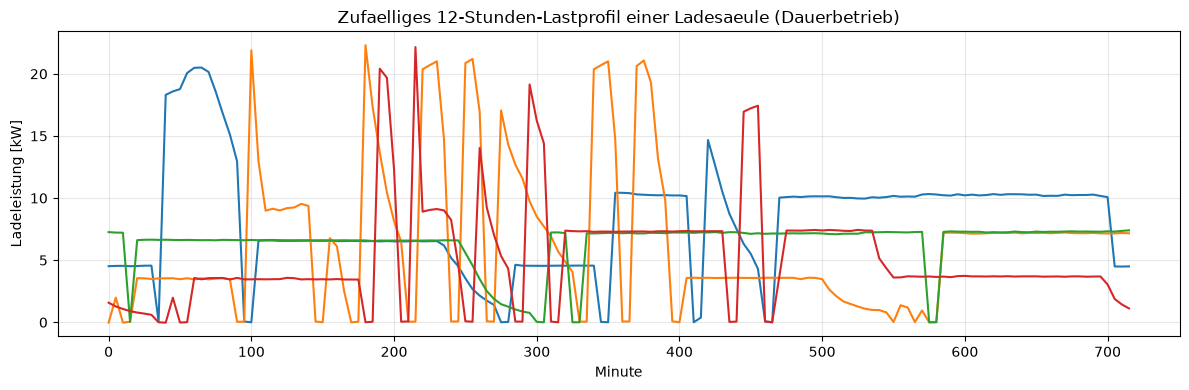

In [5]:
sys.path.append(str(Path.cwd()))

import random_lastprofile_builder as rlb
rlb = importlib.reload(rlb)
build_random_12h_lastprofile = rlb.build_random_12h_lastprofile

MINUTEN_RASTER = np.arange(0, 12 * 60, 5)  # 144 Werte, fest fuer duration_hours=12


def make_random_12h_profile(seed=None):
    """Erzeugt ein zufaelliges 12h-Lastprofil (kW) einer einzelnen,
    durchgaengig belegten Ladesaeule aus aneinandergereihten echten
    Ladevorgaengen."""
    return build_random_12h_lastprofile(random_state=seed)


# Beispielaufruf
profile_12h   = make_random_12h_profile(42)
profile_12h_2 = make_random_12h_profile(67)
profile_12h_3 = make_random_12h_profile(13)
profile_12h_4 = make_random_12h_profile(0)

plt.figure(figsize=(12, 4))
for p, c in zip([profile_12h, profile_12h_2, profile_12h_3, profile_12h_4],
                 ["tab:blue", "tab:orange", "tab:green", "tab:red"]):
    plt.plot(p["minute"], p["lastprofil"], color=c, linewidth=1.5)
plt.title("Zufaelliges 12-Stunden-Lastprofil einer Ladesaeule (Dauerbetrieb)")
plt.xlabel("Minute")
plt.ylabel("Ladeleistung [kW]")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Gleichzeitigkeitsfaktor über die Einzelmaxima der gezogenen Profile

Statt `g_real` über eine feste Referenzleistung (Nennwert oder globales
empirisches Maximum) zu normieren, wird hier die klassische Definition des
Gleichzeitigkeitsfaktors (Koinzidenzfaktor) verwendet:

$$g_{real}(n) = \dfrac{P_{agg,max}}{\sum_i P_{i,max}}$$

`P_agg,max` ist die Spitze der Summenlast aller n Säulen; `P_i,max` ist die
individuelle Spitze jeder einzelnen gezogenen Säule (also die tatsächliche
Spitzenleistung des jeweils konkret gezogenen Ladevorgangs, nicht ein
pauschaler Referenzwert). Das ist präziser als eine feste Nennleistung, weil
es berücksichtigt, dass unterschiedliche Fahrzeuge/Ladekurven in der
Stichprobe unterschiedliche Spitzenleistungen erreichen — `simultaneity_factor`
übernimmt diese Berechnung.

In [6]:
def simultaneity_factor(*profiles, return_components: bool = False):
    """Berechnet den Gleichzeitigkeitsfaktor mehrerer Lastprofile.

    Parameters
    ----------
    *profiles : sequence of pandas.DataFrame
        Jeweils ein DataFrame mit den Spalten `minute` und `lastprofil`.
    return_components : bool
        Wenn True, werden zusaetzlich (Pmax, Pmax_einzeln) zurueckgegeben.

    Returns
    -------
    float
        Der Gleichzeitigkeitsfaktor Pmax / Pmax_einzeln.
    """
    if len(profiles) == 0:
        raise ValueError("Mindestens ein Profil muss uebergeben werden.")

    dfs = []
    for p in profiles:
        if not hasattr(p, "__getitem__"):
            raise TypeError("Jedes uebergebene Profil muss ein DataFrame-aehnliches Objekt mit 'minute' und 'lastprofil' sein")
        dfs.append(p)

    import functools

    minutes_list = [df["minute"].to_numpy() for df in dfs]
    try:
        common = functools.reduce(lambda a, b: np.intersect1d(a, b), minutes_list)
    except Exception:
        common = minutes_list[0]
    if len(common) == 0:
        common = minutes_list[0]

    vals = []
    for df in dfs:
        s = df.set_index("minute")["lastprofil"].reindex(common)
        vals.append(s.to_numpy(dtype=float))
    mat = np.vstack(vals)

    agg = np.nansum(mat, axis=0)
    Pmax = float(np.nanmax(agg))
    Pmax_einzeln = float(np.nansum([np.nanmax(v) for v in mat]))

    factor = Pmax / Pmax_einzeln if Pmax_einzeln > 0 else float("nan")
    if return_components:
        return factor, Pmax, Pmax_einzeln
    return factor


def ziehe_saeulen_profile(n_saeulen, seed_start):
    """Zieht n unabhaengige 12h-Lastprofile (je ein DataFrame mit den
    Spalten 'minute' und 'lastprofil'), eigener Seed pro Saeule."""
    return [build_random_12h_lastprofile(random_state=seed_start + i) for i in range(n_saeulen)]


def profile_zu_matrix(profil_liste):
    """Wandelt eine Liste von Profil-DataFrames in eine breite Matrix
    (Spalten = Saeulen, Index = Minute) um."""
    spalten = {f"saeule_{i}": p.set_index("minute")["lastprofil"] for i, p in enumerate(profil_liste)}
    return pd.DataFrame(spalten)


def g_real_fuer_n(n_saeulen, seed_start):
    """Zieht n Saeulenprofile und berechnet g_real ueber simultaneity_factor.

    Returns
    -------
    g_real, p_agg_max_kw, p_einzeln_summe_kw, profil_liste
    """
    profil_liste = ziehe_saeulen_profile(n_saeulen, seed_start)
    g_real, p_agg_max_kw, p_einzeln_summe_kw = simultaneity_factor(*profil_liste, return_components=True)
    return g_real, p_agg_max_kw, p_einzeln_summe_kw, profil_liste

## 6. Szenarienmatrix — Netzbelastung je n_saeulen (Monte-Carlo)

Für jedes `n_saeulen` werden mehrere unabhängige 12h-Realisierungen gezogen
(eigene, nicht überlappende Seed-Blöcke je `(n, rep)`, sodass sich keine
Ladesäule zwischen Szenarien zufällig wiederholt). Für jede Realisierung wird
die EV-Spitzenlast des 12h-Fensters zusammen mit der konstanten
Haushalts-Spitzenlast (~160 kW) ins Netz eingespeist und ein Lastfluss
berechnet. So entsteht sowohl eine Verteilung für `g_real` als auch eine
konservative (Worst-Case) Aussage zur Netzbelastung.

In [7]:
n_saeulen_liste = [1, 2, 3, 4, 5, 7, 10, 12, 15, 20, 25, 30, 35, 40, 45, 50]
n_repeats = 30

ergebnisse = []

for n_saeulen in n_saeulen_liste:
    for rep in range(n_repeats):
        seed_start = n_saeulen * 100_000 + rep * 1_000  # eigener Seed-Block je (n, rep)

        g_real, p_agg_max_kw, p_einzeln_summe_kw, _ = g_real_fuer_n(n_saeulen, seed_start)

        net.load.loc[net.load["name"] == "EV_Parkplatz", "p_mw"] = p_agg_max_kw / 1000
        pp.runpp(net, algorithm="nr", numba=False)

        ergebnisse.append({
            "n_saeulen"          : n_saeulen,
            "rep"                : rep,
            "p_ev_agg_max_kw"    : p_agg_max_kw,
            "p_einzeln_summe_kw" : p_einzeln_summe_kw,
            "g_real"             : g_real,
            "vm_min_pu"       : net.res_bus["vm_pu"].min(),
            "loading_max_pct" : net.res_line["loading_percent"].max(),
            "loading_pk_pct"  : net.res_line.loc[leitung_parkplatz, "loading_percent"],
            "trafo_pct"       : net.res_trafo["loading_percent"].values[0],
            "leitung_ok"      : net.res_line["loading_percent"].max() <= 100.0,
            "trafo_ok"        : net.res_trafo["loading_percent"].values[0] <= 100.0,
            "spannung_ok"     : net.res_bus["vm_pu"].min() >= 0.95,
        })

    teil = [e for e in ergebnisse if e["n_saeulen"] == n_saeulen]
    print(f"✅ {n_saeulen:2d} Saeulen — "
          f"g_real: {np.mean([e['g_real'] for e in teil]):.2f} "
          f"(±{np.std([e['g_real'] for e in teil]):.2f}), "
          f"max. Trafo: {max(e['trafo_pct'] for e in teil):.1f}%")

matrix_df = pd.DataFrame(ergebnisse)
print("\nFertig!")

✅  1 Saeulen — g_real: 1.00 (±0.00), max. Trafo: 30.8%
✅  2 Saeulen — g_real: 0.78 (±0.12), max. Trafo: 33.2%
✅  3 Saeulen — g_real: 0.68 (±0.08), max. Trafo: 36.5%
✅  4 Saeulen — g_real: 0.60 (±0.07), max. Trafo: 36.1%
✅  5 Saeulen — g_real: 0.58 (±0.07), max. Trafo: 39.3%
✅  7 Saeulen — g_real: 0.53 (±0.05), max. Trafo: 41.0%
✅ 10 Saeulen — g_real: 0.49 (±0.05), max. Trafo: 48.1%
✅ 12 Saeulen — g_real: 0.47 (±0.05), max. Trafo: 50.7%
✅ 15 Saeulen — g_real: 0.44 (±0.04), max. Trafo: 52.7%
✅ 20 Saeulen — g_real: 0.43 (±0.03), max. Trafo: 59.8%
✅ 25 Saeulen — g_real: 0.42 (±0.05), max. Trafo: 72.8%
✅ 30 Saeulen — g_real: 0.40 (±0.03), max. Trafo: 71.6%
✅ 35 Saeulen — g_real: 0.39 (±0.03), max. Trafo: 77.5%
✅ 40 Saeulen — g_real: 0.39 (±0.03), max. Trafo: 85.6%
✅ 45 Saeulen — g_real: 0.39 (±0.02), max. Trafo: 91.2%
✅ 50 Saeulen — g_real: 0.38 (±0.02), max. Trafo: 99.0%

Fertig!


In [8]:
zusammenfassung = matrix_df.groupby("n_saeulen").agg(
    g_mean=("g_real", "mean"),
    g_std=("g_real", "std"),
    g_max=("g_real", "max"),
    trafo_mean=("trafo_pct", "mean"),
    trafo_max=("trafo_pct", "max"),
    loading_pk_mean=("loading_pk_pct", "mean"),
    loading_pk_max=("loading_pk_pct", "max"),
    vm_min=("vm_min_pu", "min"),
).reset_index()

zusammenfassung

,n_saeulen,g_mean,g_std,g_max,trafo_mean,trafo_max,loading_pk_mean,loading_pk_max,vm_min
0,1,1.000000,0.000000,1.000000,30.123789,30.841157,6.590699,8.142681,0.986871
1,2,0.780709,0.119038,0.996766,31.919753,33.177295,10.476127,13.196689,0.986600
2,3,0.681542,0.083715,0.885949,33.816424,36.538400,14.579356,20.467943,0.986208
3,4,0.598628,0.071771,0.826122,34.827801,36.125549,16.767334,19.574810,0.986256
4,5,0.578939,0.071266,0.832969,36.356730,39.284405,20.074919,26.408374,0.985886
5,7,0.526707,0.048921,0.664316,38.824543,40.995246,25.413551,30.109374,0.985685
6,10,0.488414,0.051307,0.587815,42.880608,48.116633,34.187832,45.514323,0.984840
7,12,0.467501,0.055116,0.621220,45.564469,50.665292,39.993555,51.027383,0.984536
8,15,0.441596,0.044722,0.526479,48.793499,52.687171,46.978445,55.400887,0.984293
9,20,0.432929,0.034825,0.515271,55.584415,59.770722,61.667747,70.722776,0.983437


## 7. Auswertung — g_real(n) und Netzbelastung

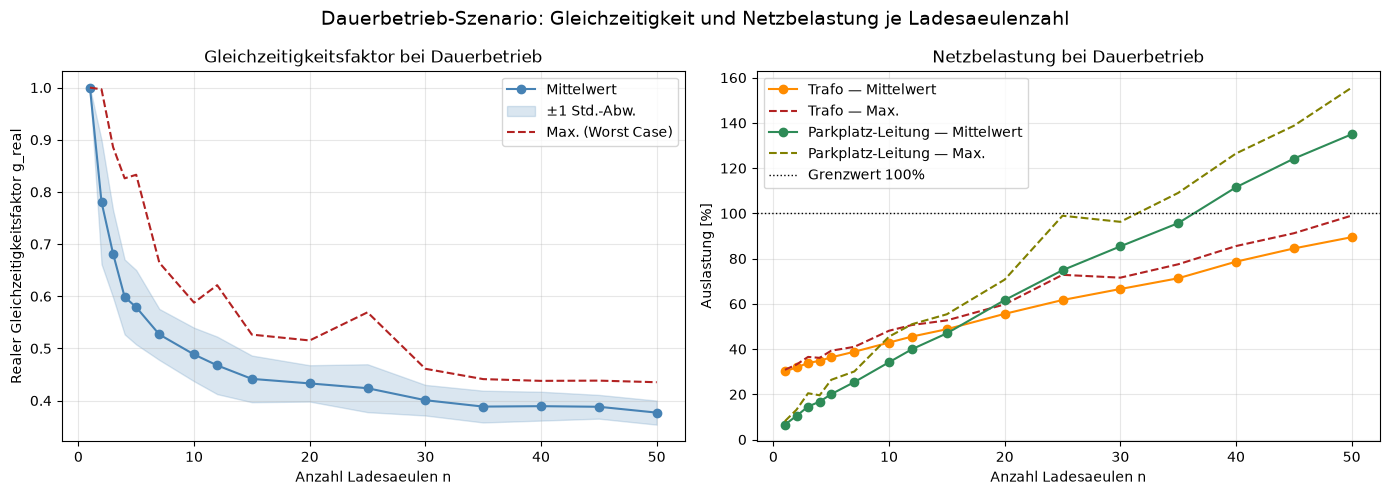

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(zusammenfassung["n_saeulen"], zusammenfassung["g_mean"],
             marker="o", color="steelblue", label="Mittelwert")
axes[0].fill_between(
    zusammenfassung["n_saeulen"],
    zusammenfassung["g_mean"] - zusammenfassung["g_std"],
    zusammenfassung["g_mean"] + zusammenfassung["g_std"],
    alpha=0.2, color="steelblue", label="±1 Std.-Abw."
)
axes[0].plot(zusammenfassung["n_saeulen"], zusammenfassung["g_max"],
             linestyle="--", color="firebrick", label="Max. (Worst Case)")
axes[0].set_xlabel("Anzahl Ladesaeulen n")
axes[0].set_ylabel("Realer Gleichzeitigkeitsfaktor g_real")
axes[0].set_title("Gleichzeitigkeitsfaktor bei Dauerbetrieb")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(zusammenfassung["n_saeulen"], zusammenfassung["trafo_mean"],
             marker="o", color="darkorange", label="Trafo — Mittelwert")
axes[1].plot(zusammenfassung["n_saeulen"], zusammenfassung["trafo_max"],
             linestyle="--", color="firebrick", label="Trafo — Max.")
axes[1].plot(zusammenfassung["n_saeulen"], zusammenfassung["loading_pk_mean"],
             marker="o", color="seagreen", label="Parkplatz-Leitung — Mittelwert")
axes[1].plot(zusammenfassung["n_saeulen"], zusammenfassung["loading_pk_max"],
             linestyle="--", color="olive", label="Parkplatz-Leitung — Max.")
axes[1].axhline(100, color="black", linestyle=":", linewidth=1.0, label="Grenzwert 100%")
axes[1].set_xlabel("Anzahl Ladesaeulen n")
axes[1].set_ylabel("Auslastung [%]")
axes[1].set_title("Netzbelastung bei Dauerbetrieb")
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.suptitle("Dauerbetrieb-Szenario: Gleichzeitigkeit und Netzbelastung je Ladesaeulenzahl", fontsize=14)
plt.tight_layout()
plt.show()

## 8. Zeitreihenanalyse — Extremszenario (n = 50, eine Realisierung)

Eine einzelne 12h-Realisierung mit der maximalen Ladesäulenzahl wird
zeitschrittweise (144 × 5-Minuten-Schritte) durch den Lastfluss gerechnet —
analog zur bisherigen Jahressimulation, nur auf das 12h-Fenster begrenzt.

In [13]:
n_saeulen_extrem = 35
seed_extrem = 999_000

profile_extrem = ziehe_saeulen_profile(n_saeulen_extrem, seed_extrem)
matrix_extrem = profile_zu_matrix(profile_extrem)
ev_last_12h = matrix_extrem.sum(axis=1)  # kW, Index = Minute

g_real_extrem, p_agg_max_extrem, p_einzeln_summe_extrem = simultaneity_factor(
    *profile_extrem, return_components=True
)

print(f"EV-Peak ({n_saeulen_extrem} Saeulen): {ev_last_12h.max():.1f} kW")
print(f"EV-Mittelwert: {ev_last_12h.mean():.1f} kW")
print(f"g_real dieser Realisierung: {g_real_extrem:.3f}")

res_vm    = {}
res_load  = {}
res_trafo = {}

for minute, p_kw in ev_last_12h.items():
    net.load.loc[net.load["name"] == "EV_Parkplatz", "p_mw"] = p_kw / 1000
    pp.runpp(net, algorithm="nr", numba=False)

    res_vm[minute]    = net.res_bus["vm_pu"].copy()
    res_load[minute]  = net.res_line["loading_percent"].copy()
    res_trafo[minute] = net.res_trafo["loading_percent"].values[0]

vm_pu_df     = pd.DataFrame.from_dict(res_vm,   orient="index")
loading_df   = pd.DataFrame.from_dict(res_load, orient="index")
trafo_series = pd.Series(res_trafo)

print(f"Max. Leitungsauslastung: {loading_df.max().max():.1f}%")
print(f"Max. Trafo-Auslastung:   {trafo_series.max():.1f}%")
print(f"Min. Busspannung:        {vm_pu_df.min().min():.4f} pu")

EV-Peak (35 Saeulen): 285.9 kW
EV-Mittelwert: 202.2 kW
g_real dieser Realisierung: 0.389
Max. Leitungsauslastung: 99.7%
Max. Trafo-Auslastung:   73.2%
Min. Busspannung:        0.9818 pu


## 9. Zeitreihen-Plots

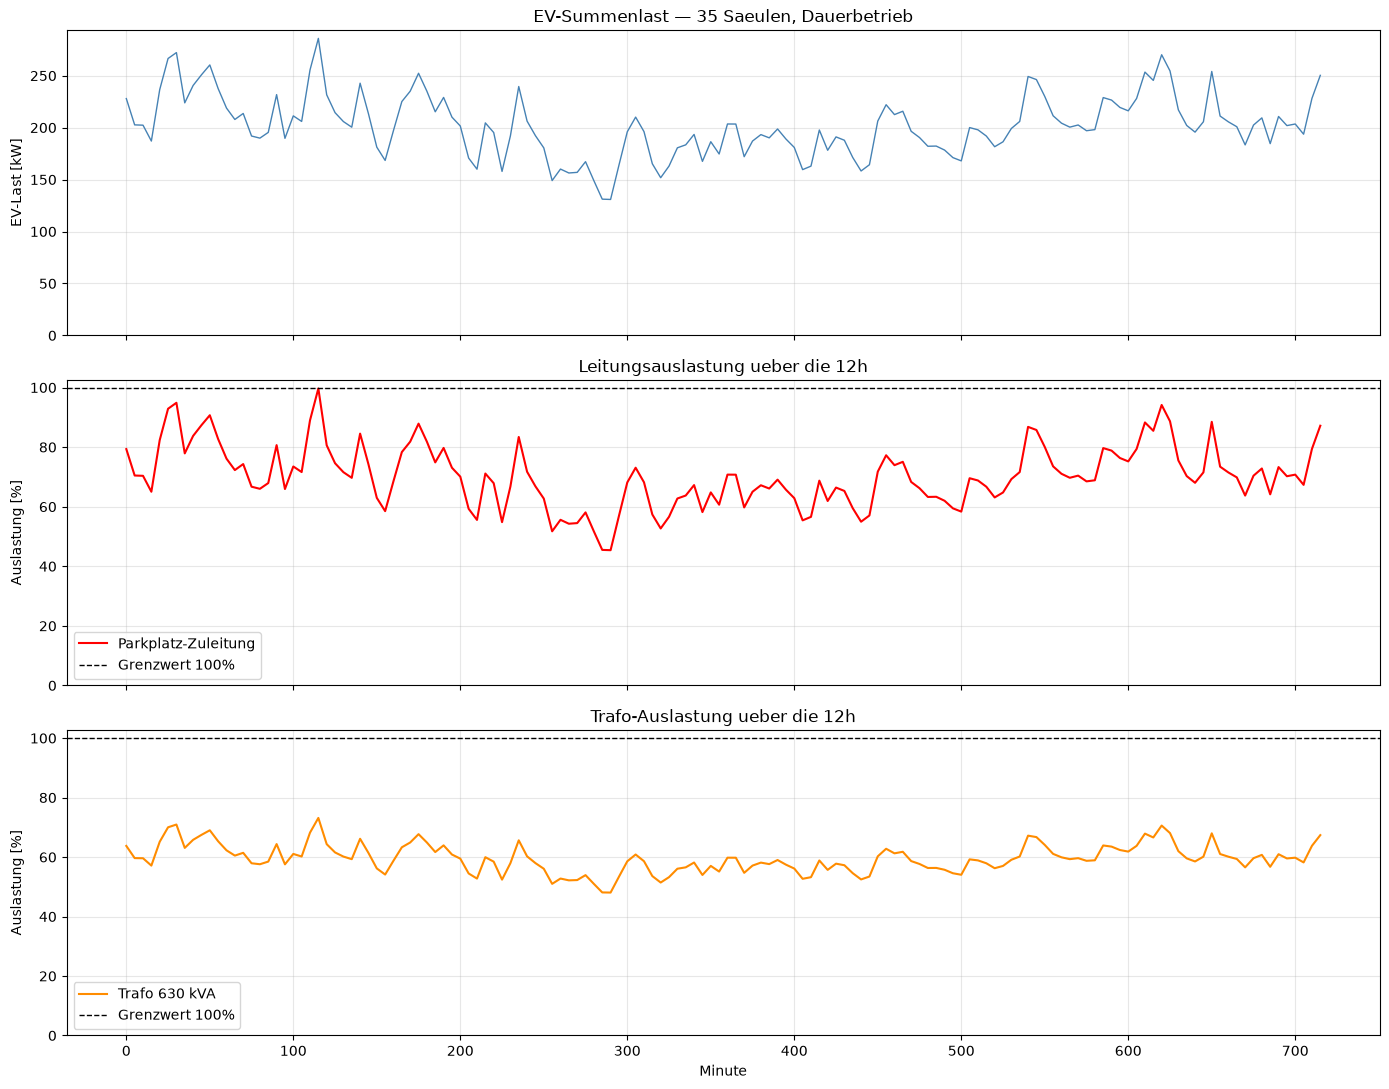

In [16]:
fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)

axes[0].plot(ev_last_12h.index, ev_last_12h.values, color="steelblue", linewidth=1.0)
axes[0].set_ylabel("EV-Last [kW]")
axes[0].set_title(f"EV-Summenlast — {n_saeulen_extrem} Saeulen, Dauerbetrieb")
axes[0].set_ylim(bottom=0)
axes[0].grid(True, alpha=0.3)

axes[1].plot(loading_df.index, loading_df[leitung_parkplatz].values,
             color="red", linewidth=1.5, label="Parkplatz-Zuleitung")
axes[1].axhline(100, color="black", linestyle="--", linewidth=1.0, label="Grenzwert 100%")
axes[1].set_ylabel("Auslastung [%]")
axes[1].set_title("Leitungsauslastung ueber die 12h")
axes[1].set_ylim(bottom=0)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(trafo_series.index, trafo_series.values,
             color="darkorange", linewidth=1.5, label="Trafo 630 kVA")
axes[2].axhline(100, color="black", linestyle="--", linewidth=1.0, label="Grenzwert 100%")
axes[2].set_xlabel("Minute")
axes[2].set_ylabel("Auslastung [%]")
axes[2].set_title("Trafo-Auslastung ueber die 12h")
axes[2].set_ylim(bottom=0)
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

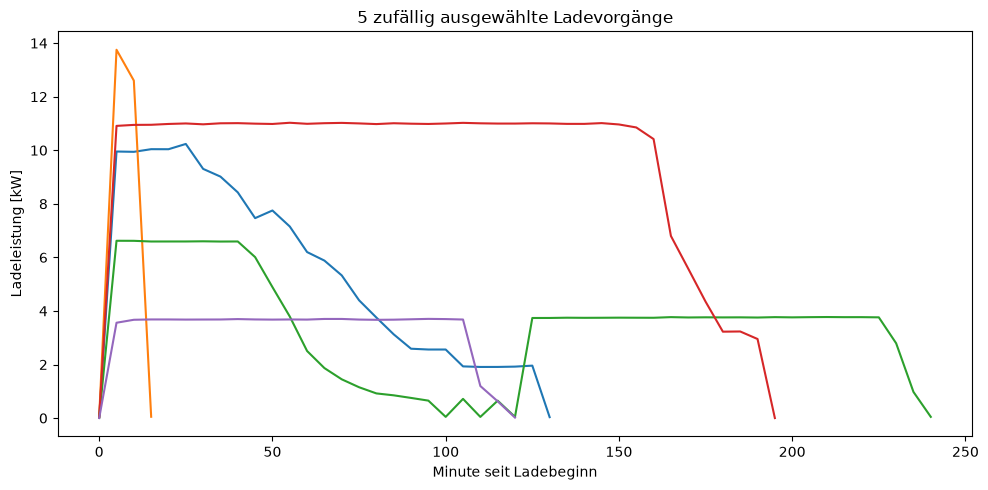

In [12]:
df = pd.read_csv("C:\\Users\\huttm\\Desktop\\Master EE\\SNEE\\SNEE_2026\\data\\e_ladelasten\\EV_Lastprofile_gefiltert.csv", index_col="minute")

sample_cols = np.random.choice(df.columns, size=5, replace=False)

plt.figure(figsize=(10, 5))
for col in sample_cols:
    serie = df[col].dropna()
    plt.plot(serie.index, serie.values, linewidth=1.5, label=col)
plt.xlabel("Minute seit Ladebeginn")
plt.ylabel("Ladeleistung [kW]")
plt.title("5 zufällig ausgewählte Ladevorgänge")
plt.tight_layout()
plt.show()